# SIOC 251 – Homework 1 

**Name:** Claire Liu   
**Date:** 4/7/26

## Part I: Building the Monte Carlo Model

Simulate a homogeneous, purely absorbing atmosphere with geometric thickness equal to one atmospheric scale height $Z_{\text{atm}}$. Photons enter at the top of the atmosphere and travel downward along a slant path determined by the solar zenith angle $\theta$.

**Extinction probability:** The probability that a photon travels an optical depth $\tau$ without being absorbed is

$$P(\tau) = e^{-\tau}$$

**Inverse CDF sampling:** To sample the random optical depth a photon travels before extinction, draw $\zeta \sim \text{Uniform}(0,1)$ and compute

$$\tau = -\ln(1 - \zeta)$$

**Geometric pathlength:** The physical distance traveled corresponding to the sampled optical depth is

$$L = \frac{Z_{\text{atm}}}{\mu} \cdot \frac{\tau}{\tau^*}$$

where $\mu = \cos\theta$ is the cosine of the solar zenith angle and $\tau^*$ is the total optical depth of the atmosphere.

**Survival condition:** A photon reaches the surface if its path length >= pathlenght of the entire atmosphere at the same angle.

In [76]:
import numpy as np

In [77]:
def monte_carlo_extinction(n_photons, tau_star, mu=1.0, z_atm=1.0):
    zeta = np.random.uniform(0, 1, n_photons)
    tau_sampled = -np.log(1 - zeta)
    path= z_atm*tau_sampled*mu/(tau_star*mu)
    
    reached_surface = reached_surface = path >= z_atm / mu
    transmittance = np.sum(reached_surface) / n_photons
    
    extinct = ~reached_surface
    extinction_heights = z_atm * (1 - tau_sampled[extinct] / tau_star)
    
    return transmittance, extinction_heights

## Part II: Model Verification

Verification 1: I used Beer's law $T = e^{-\tau^* / \mu}$ to calculate the transmittance and compared it with the results from the model, they should give similar values.


In [78]:
t, heights = monte_carlo_extinction(n_photons=100000, tau_star=0.5, mu=np.cos(0.78))
tau_star=0.5
mu=np.cos(0.78)
print(f"MC transmittance: {t:.4f}")
print(f"Beer's Law:       {np.exp(-tau_star / mu):.4f}")

MC transmittance: 0.4960
Beer's Law:       0.4949


Verification 2: The transmittance of a transparent atmosphere (with close to 0 total optical depth) should be close to 1.

In [79]:
t, heights = monte_carlo_extinction(n_photons=100000, tau_star=0.00001, mu=np.cos(0.78))
print(f"MC transmittance: {t:.4f}")

MC transmittance: 1.0000


Models behave as expected.

## Part III: Radiative Transfer Experiments

1. For the sun directly overhead (θ = 0), what is the value of optical depth τ that results in an
e-folding reduction in surface intensity?

For an e-folding reduction in intensity, t = 1/e(mu=1 for θ = 0), and therefore τ=1.

In [80]:
t, heights = monte_carlo_extinction(n_photons=100000, tau_star=0.5, mu=np.cos(np.deg2rad(0)))
tau_star=0.5
mu=np.cos(np.deg2rad(0))
print(f"MC transmittance: {t:.4f}")
print(f"Beer's Law:       {np.exp(-tau_star / mu):.4f}")

MC transmittance: 0.6055
Beer's Law:       0.6065


2. For τ = 1, what is the surface transmittance t when the solar zenith angle is 60◦?

In [81]:
tau_star=1
mu=np.cos(np.deg2rad(60))
t, heights = monte_carlo_extinction(n_photons=100000, tau_star=1, mu=np.cos(np.deg2rad(60)))
print(f"MC transmittance: {t:.4f}")
print(f"Beer's Law:       {np.exp(-tau_star / mu):.4f}")

MC transmittance: 0.1356
Beer's Law:       0.1353


3. Explain why, in a purely absorbing atmosphere, the surface would be dark when the sun reaches the horizon (assume the sun is a point source).

In [82]:
tau_star=1
mu=np.cos(np.deg2rad(90))
t, heights = monte_carlo_extinction(n_photons=100000, tau_star=1, mu=np.cos(np.deg2rad(90)))
print(f"MC transmittance: {t:.4f}")
print(f"Beer's Law:       {np.exp(-tau_star / mu):.4f}")

MC transmittance: 0.0000
Beer's Law:       0.0000


The zenith angle is 90 degrees when the sun reaches the horizon. In that case, the transmittance is 0 which means everything was absorbed and the surface would be dark.

4. For τ = 1, 3, and 10, how does transmittance vary with height in the atmosphere?

In [83]:
import matplotlib.pyplot as plt

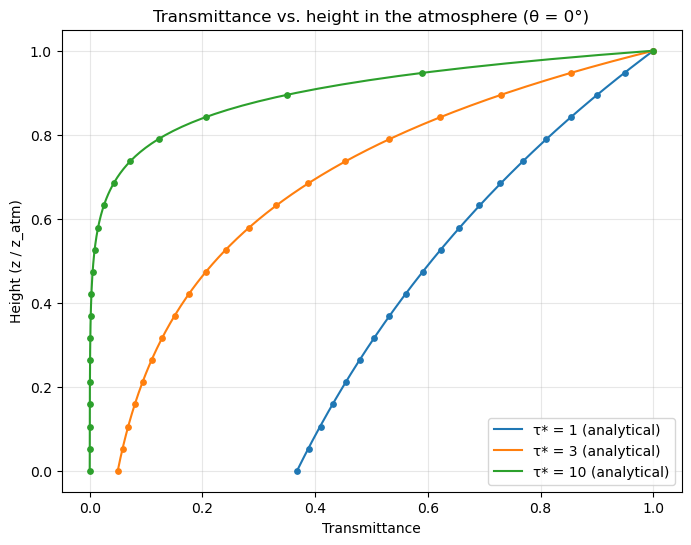

In [84]:
# At height z, the photon has only passed through the atmosphere above z.
# Vertical optical depth from TOA to height z: tau(z) = tau_star * (1 - z/z_atm)
# Transmittance at height z: exp(-tau_star * (1 - z/z_atm) / mu)

z_atm = 1.0
z = np.linspace(0, z_atm, 200)
mu = 1.0  # overhead sun

fig, ax = plt.subplots(figsize=(8, 6))

for tau_star in [1, 3, 10]:
    # Analytical
    t_z = np.exp(-tau_star * (1 - z / z_atm) / mu)
    ax.plot(t_z, z / z_atm, label=f'τ* = {tau_star} (analytical)')
    
    # MC: for each height level, count fraction of photons that made it past that level
    n_photons = 500_000
    zeta = np.random.uniform(0, 1, n_photons)
    tau_sampled = -np.log(1 - zeta)
    
    z_levels = np.linspace(0, z_atm, 20)
    t_mc = []
    for zl in z_levels:
        tau_to_zl = tau_star * (1 - zl / z_atm) / mu
        t_mc.append(np.mean(tau_sampled >= tau_to_zl))
    ax.scatter(t_mc, z_levels / z_atm, s=15, zorder=5)

ax.set_xlabel('Transmittance')
ax.set_ylabel('Height (z / z_atm)')
ax.set_title('Transmittance vs. height in the atmosphere (θ = 0°)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('figures/q4_transmittance_vs_height.png', dpi=150, bbox_inches='tight')
plt.show()

At greater optical depth, most of the extinction happens in the upper portion of the atmosphere, and transmittance drops to near zero before the photon reaches the lower atmosphere. For τ*=10, practically all photons are absorbed in the top of the atmosphere, while for τ*=1 the absorption is spread more evenly throughout.

## Part IV: AERONET Observations

In [85]:
import pandas as pd

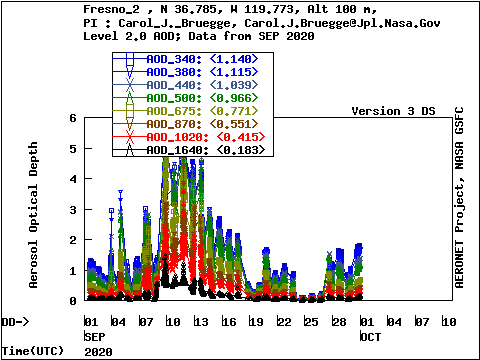

In [86]:
from IPython.display import Image
Image(filename='draw_data_chart_v3.gif', width=500)

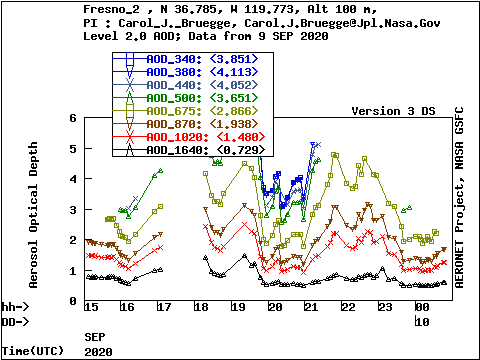

In [87]:
from IPython.display import Image
Image(filename='draw_data_chart_v3-1.gif', width=500)

In [88]:
aod_col = 'AOD_500nm'
sza_col = 'Solar_Zenith_Angle(Degrees)'

In [89]:
def beer_lambert(tau_star, mu=1.0):
    return np.exp(-tau_star / mu)

Selected day: 2020-09-09
AOD range: 2.570 – 5.712

Primary aerosol source: wildfire smoke (biomass burning)
The Creek Fire ignited Sept 4, 2020 ~50 miles NE of Fresno


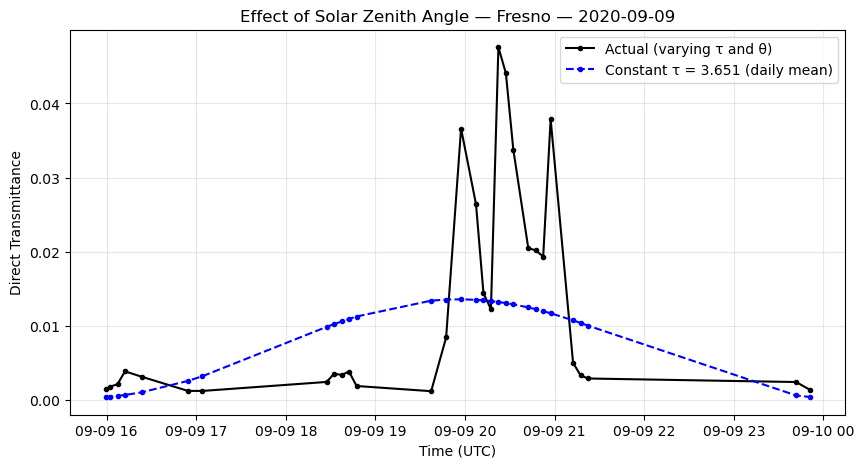

In [90]:
# ---- Load data ----
df = pd.read_csv('20200901_20200930_Fresno_2.lev20', skiprows=6)
df.columns = df.columns.str.strip()

df[aod_col] = df[aod_col].replace(-999.0, np.nan)
df[sza_col] = df[sza_col].replace(-999.0, np.nan)
df = df.dropna(subset=[aod_col, sza_col])

df['datetime'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'],
                                 format='%d:%m:%Y %H:%M:%S')
df['date'] = df['datetime'].dt.date
# ---- Pick day with most variability ----
daily_std = df.groupby('date')[aod_col].std()
best_day = daily_std.idxmax()
day = df[df['date'] == best_day].copy()
print(f"Selected day: {best_day}")
print(f"AOD range: {day[aod_col].min():.3f} – {day[aod_col].max():.3f}")

tau = day[aod_col].values
mu = np.cos(np.radians(day[sza_col].values))
tau_mean = np.mean(tau)

print(f"\nPrimary aerosol source: wildfire smoke (biomass burning)")
print(f"The Creek Fire ignited Sept 4, 2020 ~50 miles NE of Fresno")
day['local_time'] = day['datetime'] - pd.Timedelta(hours=7)

t_actual = beer_lambert(tau, mu)

t_const_tau = beer_lambert(tau_mean, mu)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(day['datetime'], t_actual, 'k-o', markersize=3, label='Actual (varying τ and θ)')
ax.plot(day['datetime'], t_const_tau, 'b--o', markersize=3,
        label=f'Constant τ = {tau_mean:.3f} (daily mean)')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Direct Transmittance')
ax.set_title(f'Effect of Solar Zenith Angle — Fresno — {best_day}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('figures/part4_transmittance_const_tau.png', dpi=150, bbox_inches='tight')
plt.show()

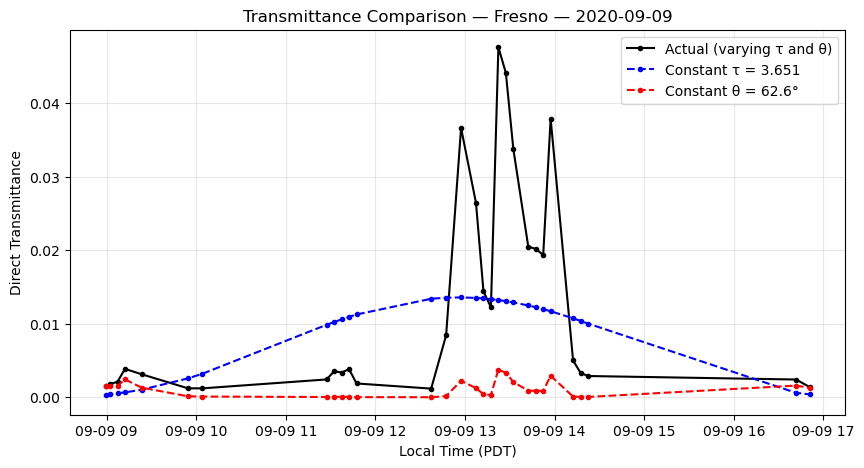

Transmittance spread from θ variation alone: 0.0132
Transmittance spread from τ variation alone: 0.0038


In [102]:
# Constant theta (max SZA of the day), varying tau
sza_max = day[sza_col].max()
mu_const = np.cos(np.radians(sza_max))
t_const_theta = beer_lambert(tau, mu_const)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(day['local_time'], t_actual, 'k-o', markersize=3, label='Actual (varying τ and θ)')
ax.plot(day['local_time'], t_const_tau, 'b--o', markersize=3,
        label=f'Constant τ = {tau_mean:.3f}')
ax.plot(day['local_time'], t_const_theta, 'r--o', markersize=3,
        label=f'Constant θ = {sza_max:.1f}°')
ax.set_xlabel('Local Time (PDT)')
ax.set_ylabel('Direct Transmittance')
ax.set_title(f'Transmittance Comparison — Fresno — {best_day}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('figures/part4_transmittance_all.png', dpi=150, bbox_inches='tight')
plt.show()

# Which factor dominates?
spread_const_tau = t_const_tau.max() - t_const_tau.min()    # variation from theta alone
spread_const_theta = t_const_theta.max() - t_const_theta.min()  # variation from tau alone
print(f"Transmittance spread from θ variation alone: {spread_const_tau:.4f}")
print(f"Transmittance spread from τ variation alone: {spread_const_theta:.4f}")

1. The primary source at this station is the wildfire smoke, which ignited September 4, 2020 about 50 miles northeast of Fresno in the Sierra National Forest.
2. Transmittance peaks in the noon/afternoon(local time).
3. With constant τ, the transmittance follows a smooth U-shape, lowest at sunrise/sunset when zenith angle is large, highest at solar noon when the sun is overhead.
4. Transimittance also peaks in the afternoon, shape looks similar to the actual transmittances but lower in values.
5. AOD is most responsible for the changes in transmittance in this case as it leads to more variations when zenith angle was kept constant.

## Part V: Student Investigation

I wonder how many photons does the model need to simulate before the Monte Carlo transmittance converges to the analytical valuem and if that depends on optical depth.

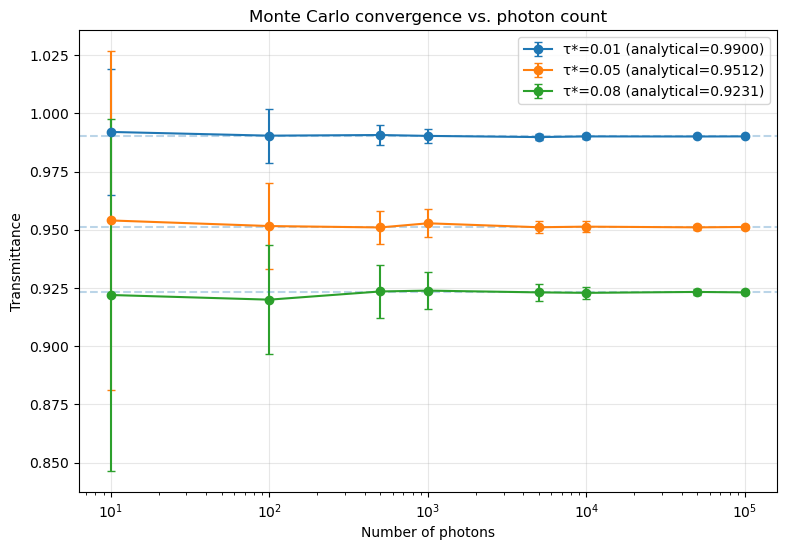

In [99]:
n_values = [10,100, 500, 1000, 5000, 10_000, 50_000, 100_000]
n_trials = 50  

fig, ax = plt.subplots(figsize=(9, 6))

for tau_star in [0.01, 0.05, 0.08]:
    t_analytical = beer_lambert(tau_star, mu=1.0)
    
    means = []
    stds = []
    for n in n_values:
        trials = []
        for _ in range(n_trials):
            t, _ = monte_carlo_extinction(n, tau_star, mu=1.0)
            trials.append(t)
        means.append(np.mean(trials))
        stds.append(np.std(trials))
    
    ax.errorbar(n_values, means, yerr=stds, marker='o', capsize=3, 
                label=f'τ*={tau_star} (analytical={t_analytical:.4f})')
    ax.axhline(t_analytical, linestyle='--', alpha=0.3)

ax.set_xscale('log')
ax.set_xlabel('Number of photons')
ax.set_ylabel('Transmittance')
ax.set_title('Monte Carlo convergence vs. photon count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('figures/q5_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

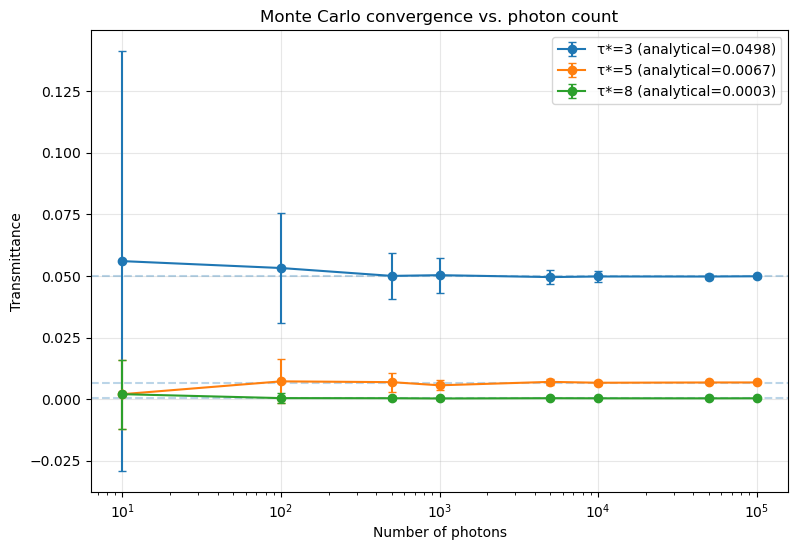

In [100]:
n_values = [10,100, 500, 1000, 5000, 10_000, 50_000, 100_000]
n_trials = 50  

fig, ax = plt.subplots(figsize=(9, 6))

for tau_star in [3, 5, 8]:
    t_analytical = beer_lambert(tau_star, mu=1.0)
    
    means = []
    stds = []
    for n in n_values:
        trials = []
        for _ in range(n_trials):
            t, _ = monte_carlo_extinction(n, tau_star, mu=1.0)
            trials.append(t)
        means.append(np.mean(trials))
        stds.append(np.std(trials))
    
    ax.errorbar(n_values, means, yerr=stds, marker='o', capsize=3, 
                label=f'τ*={tau_star} (analytical={t_analytical:.4f})')
    ax.axhline(t_analytical, linestyle='--', alpha=0.3)

ax.set_xscale('log')
ax.set_xlabel('Number of photons')
ax.set_ylabel('Transmittance')
ax.set_title('Monte Carlo convergence vs. photon count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('figures/q5_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

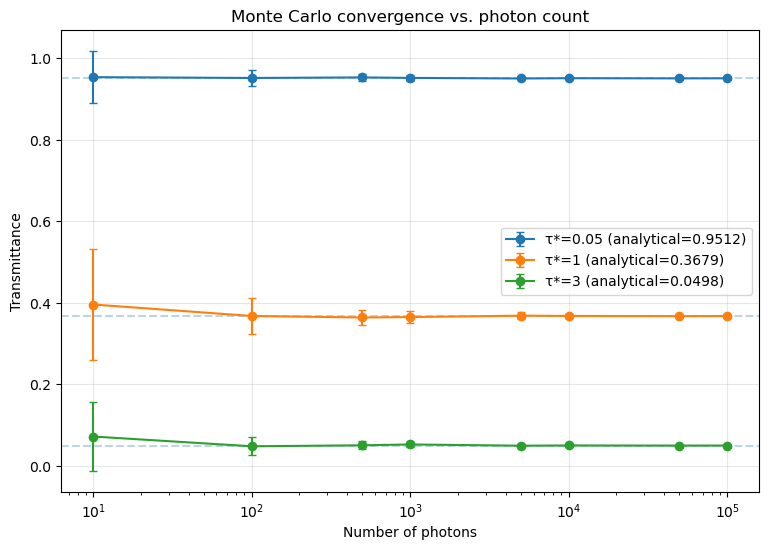

In [101]:
n_values = [10,100, 500, 1000, 5000, 10_000, 50_000, 100_000]
n_trials = 50  

fig, ax = plt.subplots(figsize=(9, 6))

for tau_star in [0.05, 1,3]:
    t_analytical = beer_lambert(tau_star, mu=1.0)
    
    means = []
    stds = []
    for n in n_values:
        trials = []
        for _ in range(n_trials):
            t, _ = monte_carlo_extinction(n, tau_star, mu=1.0)
            trials.append(t)
        means.append(np.mean(trials))
        stds.append(np.std(trials))
    
    ax.errorbar(n_values, means, yerr=stds, marker='o', capsize=3, 
                label=f'τ*={tau_star} (analytical={t_analytical:.4f})')
    ax.axhline(t_analytical, linestyle='--', alpha=0.3)

ax.set_xscale('log')
ax.set_xlabel('Number of photons')
ax.set_ylabel('Transmittance')
ax.set_title('Monte Carlo convergence vs. photon count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('figures/q5_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

They all converge fairly fast within 100-1000 photons tested. I didn't see a linear relationship between optical depth and how fast the model converges. But it seems that it genrally converges faster when the values are within 0-1.

# AI Usage
Tool used: Claude 

How it was used: I used Claude to write the monte carlo model and pmake plots for part III q4, part IV, part V. 

What I changed: I went over the code, modified the code for the model(there was an error where tao was used instead of tao(z) which made errors in the first place, the model and the Beer's law gave different results), and changed parameters(tao, tao_star, n, etc) to make the plots.

How I verified the result: I verifed the results using Beer's law and calculated the transmittance of a tansparent atmosphere(t=1).